# 数据聚合与分组处理

对数据集进行分类并对各组数据调用聚合或转换函数，通常是数据分析工作中的重要环节。在将数据集加载、合并、预处理之后，通常就是计算分组统计信息或生成透视表，以用于报告或数据可视化。pandas提供了一个灵活高效的gruopby接口，它使你能以一种自然的方式对数据集进行切片、切块和汇总等操作。

关系型数据库和SQL（Structured Query Language，结构化查询语言）能够如此流行的原因之一，就是其能够方便地对数据进行连接、过滤、转换和聚合。但是，像SQL这样的查询语言所能执行的分组运算的种类很有限。在本章中你将会看到，得益于Python和pandas强大的表达能力，通过自定义的Python函数操控数据的各个分组，我们可以执行复杂的分组运算。在本章中，你将学到：

- 使用单键或多键（形式可以是函数、数组或DataFrame列名）分割pandas对象。
- 计算分组汇总统计，比如计数、平均值或标准差，或用户定义的函数。
- 应用组内转换或其他操作，如正态化、线性回归、排名或选取子集等。
- 计算透视表和交叉表。
- 执行分位数分析以及其他统计分组分析。

> 对时间序列数据的聚合（groupby的特殊用法之一），在本书中称作重采样，将在第11章中单独对其进行讲解。

## GroupBy机制

Hadley Wickham（R语言中许多热门包的作者）创造了一个用于描述分组运算的术语“拆分-应用-联合”(split-apply-combine)。首先，pandas对象（无论是Series、DataFrame还是其他）中的数据会根据你所提供的单键或多键拆分为多组。拆分操作是在对象的特定轴上执行的。例如，DataFrame可以在其行(axis="index")或列(axis="columns")上进行分组。其次，将一个函数应用到各个分组，并产生一个新值。最后，所有这些函数的执行结果会联合为最终的结果对象。结果对象的形式一般取决于对数据所执行的操作。图10-1对简单的聚合过程做了大致说明。

![10-1分组聚合图示.png](images/10-1分组聚合图示.png)

每个分组键可以有多种形式，并且类型不必相同：
- 值列表或值数组，其长度与待分组的轴一样
- 在DataFrame中指明列名的值
- 字典或Series，给出待分组轴上的值与分组名之间的对应关系
- 可以在轴索引或索引各标签上调用的函数

首先来看下面这个DataFrame——一个非常简单的表格型数据集：

In [2]:
import numpy as np
import pandas as pd
df = pd.DataFrame({'key1': ['a', 'a', None, 'b', 'b', 'a', None],
                   'key2': pd.Series([1, 2, 1, 2, 1, None, 1], dtype='Int64'),
                   'data1': np.random.standard_normal(7),
                   "data2": np.random.standard_normal(7)})

df

,key1,key2,data1,data2
0,a,1,0.986752,-0.157549
1,a,2,-0.405507,0.394556
2,None,1,0.299189,-0.865091
3,b,2,-0.200698,0.660541
4,b,1,-0.156605,2.050585
5,a,<NA>,0.191453,2.032655
6,None,1,-1.354255,1.324156


假设你想要按key1标签进行分组，并计算data1列的平均值。有多种方法可以实现，其中一种方法是访问data1，并使用key1列（这是一个Series）调用groupby方法：


In [3]:
grouped = df['data1'].groupby(df['key1'])
grouped

变量grouped是一个特殊的GroupBy对象。它实际上还没有进行任何计算，只是包含一些有关分组键df["key1"]的中间数据而已。换句话说，该对象已经有了接下来对各分组执行运算所需的一切信息。例如，我们可以调用GroupBy对象的mean方法来计算分组平均值：

In [4]:
grouped.mean()

key1
a    0.257566
b   -0.178651
Name: data1, dtype: float64

10.2节将详细讲解.mean()的调用过程。这里最重要的是，通过分组键对数据数据(Series)进行分割，然后做了聚合，并生成了一个新Series，其索引为key1列中的唯一值。之所以结果中索引的名称为key1，是因为原始DataFrame的df["key1"]的列名就是如此。

如果我们一次传入包含多个数组的列表，就会得到不同的结果：

In [5]:
means = df['data1'].groupby([df['key1'], df['key2']]).mean()
means

key1  key2
a     1       0.986752
      2      -0.405507
b     1      -0.156605
      2      -0.200698
Name: data1, dtype: float64

这里，我通过两个键对数据进行了分组，得到的Series具有一个层次化索引，由唯一的键对组成：


In [6]:
means.unstack()

key2,1,2
key1,,
a,0.986752,-0.405507
b,-0.156605,-0.200698


在这个例子中，分组键均为Series。实际上，分组键可以是长度正确的任意数组：

In [7]:
states = np.array(["OH", "CA", "CA", "OH", "OH", "CA", "OH"])
years = np.array([2005, 2005, 2006, 2005, 2006, 2005, 2006])

df['data1'].groupby([states, years]).mean()

CA  2005   -0.107027
    2006    0.299189
OH  2005    0.393027
    2006   -0.755430
Name: data1, dtype: float64

对于要处理的DataFrame，分组信息往往就位于其中。在这种情况下，你可以将列名（无论是字符串、数字还是其他Python对象）用作分组键：


In [8]:
df.groupby('key1').mean()

,key2,data1,data2
key1,,,
a,1.5,0.257566,0.756554
b,1.5,-0.178651,1.355563


In [9]:
df[['key2', 'data1', 'data2']].groupby('key2').mean()

,data1,data2
key2,,
1,-0.056230,0.588025
2,-0.303102,0.527549


In [10]:
df.groupby(['key1', 'key2']).mean()

data1     data2
key1 key2                    
a    1     0.986752 -0.157549
     2    -0.405507  0.394556
b    1    -0.156605  2.050585
     2    -0.200698  0.660541

无论使用groupby的目的是什么，GroupBy对象的size方法都很实用，它可以返回一个含有分组大小的Series：


In [11]:
df.groupby(['key1', 'key2']).size()

key1  key2
a     1       1
      2       1
b     1       1
      2       1
dtype: int64

注意，任何分组关键字中的缺失值，默认都会从结果中除去。向groupby中传入dropna=False可以禁用该功能

In [12]:
df.groupby("key1", dropna=False).size()

key1
a      3
b      2
NaN    2
dtype: int64

In [13]:
df.groupby(['key1', 'key2'], dropna=False).size()

key1  key2
a     1       1
      2       1
      <NA>    1
b     1       1
      2       1
NaN   1       2
dtype: int64

在分组函数中，与size具有一定相似性的是count方法，它可以计算每个分组中非空值的数量：

In [14]:
df.groupby('key1').count()

,key2,data1,data2
key1,,,
a,2,3,3
b,2,2,2


### 10.1.1 对分组进行迭代

groupby返回的对象支持迭代，可以产生一个二元组构成的序列，每个元组包含分组名和数据块。看下面的例子：

In [15]:
for name, group in df.groupby('key1'):
    print(f"Group name: {name}")
    print(group)
    print()

Group name: a
  key1  key2     data1     data2
0    a     1  0.986752 -0.157549
1    a     2 -0.405507  0.394556
5    a  <NA>  0.191453  2.032655

Group name: b
  key1  key2     data1     data2
3    b     2 -0.200698  0.660541
4    b     1 -0.156605  2.050585



对于具有多个分组键的情况，元组的第一个元素是由键值组成的元组：

In [16]:
for (k1, k2), group in df.groupby(['key1', 'key2']):
    print(f"Group key1: {k1}, key2: {k2}")
    print(group)
    print()

Group key1: a, key2: 1
  key1  key2     data1     data2
0    a     1  0.986752 -0.157549

Group key1: a, key2: 2
  key1  key2     data1     data2
1    a     2 -0.405507  0.394556

Group key1: b, key2: 1
  key1  key2     data1     data2
4    b     1 -0.156605  2.050585

Group key1: b, key2: 2
  key1  key2     data1     data2
3    b     2 -0.200698  0.660541



当然，你可以对这些数据块做任何操作。你可能会觉得这个运算很有用，用一行代码计算得到一个包含这些数据块的字典：

In [17]:
pieces = {name: group for name, group in df.groupby('key1')}
pieces['b']

,key1,key2,data1,data2
3,b,2,-0.200698,0.660541
4,b,1,-0.156605,2.050585


groupby默认是在axis="index"上进行分组的，通过设置也可以在任意其他轴上进行分组。还是以df为例，我们可以根据其列是以"key"还是"data"开头进行分组

In [18]:
grouped = df.groupby({"key1": "key", "key2": "key", "data1": "data", "data2": "data"}, axis="columns")
grouped

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/864351277.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped = df.groupby({"key1": "key", "key2": "key", "data1": "data", "data2": "data"}, axis="columns")


### 10.1.2 选取一列或多列

使用单个列名或列名数组对由DataFrame创建的GroupBy对象建立索引，能实现选取部分列并进行聚合的效果。这表明：

In [19]:
df.groupby('key1')['data1']
df.groupby('key1')[['data2']]

是以下代码的语法糖：

In [20]:
df['data1'].groupby(df['key1'])
df[['data2']].groupby(df['key1'])

尤其是对于大型数据集，可能只想对部分列进行聚合。例如，对于前面的数据集，如果只需计算data2列的平均值并以DataFrame形式得到结果，可以这样写：


In [21]:
df.groupby(['key1', 'key2'])[['data2']].mean()

data2
key1 key2          
a    1    -0.157549
     2     0.394556
b    1     2.050585
     2     0.660541

In [22]:
df.groupby(['key1', 'key2'])['data2'].mean()

key1  key2
a     1      -0.157549
      2       0.394556
b     1       2.050585
      2       0.660541
Name: data2, dtype: float64

如果传入的是列表或数组，则该索引操作所返回的对象是一个经过分组的DataFrame。如果传入的是标量形式的单个列名，则返回的对象为经过分组的Series。

### 10.1.3 利用字典和Series进行分组

除了数组，分组信息还能以其他形式存在。来看另一个示例DataFrame：

In [23]:
people = pd.DataFrame(np.random.standard_normal((5, 5)),
                      columns=['a', 'b', 'c', 'd', 'e'],
                      index=['Joe', 'Steve', 'Wes', 'Jim', 'Travis'])
people.iloc[2:3, [1, 2]] = np.nan  # introduce a NaN
people

,a,b,c,d,e
Joe,0.338155,-0.620589,1.670889,0.339950,-0.615544
Steve,0.930100,-0.451431,-0.702183,0.708339,-2.133655
Wes,-0.866844,NaN,NaN,0.289501,0.971989
Jim,-2.398788,-1.626894,-2.158705,-0.628364,-0.162068
Travis,-0.904667,-0.145840,-0.232285,-1.201377,0.077973


现在，假设已知列的分组关系，并希望根据分组计算列的和：

In [24]:
mapping = {'a': 'red', 'b': 'red', 'c': 'blue', 'd': 'blue', 'e': 'red', 'f': 'orange'}
mapping

{'a': 'red', 'b': 'red', 'c': 'blue', 'd': 'blue', 'e': 'red', 'f': 'orange'}

现在，可以将这个字典传给groupby来构造数组，但我们可以直接传递字典（这里包含了键"f"，用于强调即使存在未使用的分组键也是可以的）：

In [25]:
by_column = people.T.groupby(mapping)
by_column.mean()

,Joe,Steve,Wes,Jim,Travis
blue,1.005419,0.003078,0.289501,-1.393534,-0.716831
red,-0.299326,-0.551662,0.052573,-1.395917,-0.324178


Series也有同样的功能，可以看作固定大小的映射

In [26]:
map_series = pd.Series(mapping)
map_series

a       red
b       red
c      blue
d      blue
e       red
f    orange
dtype: object

In [27]:
people.T.groupby(map_series).mean()

,Joe,Steve,Wes,Jim,Travis
blue,1.005419,0.003078,0.289501,-1.393534,-0.716831
red,-0.299326,-0.551662,0.052573,-1.395917,-0.324178


### 10.1.4 利用函数进行分组

与使用字典或Series相比，使用Python函数是一种更加通用的定义分组映射的方式。任何作为分组键的函数都会在各个索引值上调用一次（如果使用axis="columns"，则在各个列上调用一次函数），其返回值会用作分组名称。具体地讲，以上一小节的示例DataFrame为例，其索引值为人的名字。假设你想根据人名长度分组。虽然可以计算一个字符串长度的数组，但更简单的方法是传入len函数：

In [28]:
people.groupby(len).mean()

,a,b,c,d,e
3,-0.975826,-1.123741,-0.243908,0.000362,0.064792
5,0.930100,-0.451431,-0.702183,0.708339,-2.133655
6,-0.904667,-0.145840,-0.232285,-1.201377,0.077973


将函数与数组、列表、字典、Series混合使用也不是问题，因为它们在内部都会转换为数组：

In [29]:
key_list = ['one', 'one', 'one', 'two', 'two']
people.groupby([len, key_list]).mean()

a         b         c         d         e
3 one -0.264344 -0.620589  1.670889  0.314725  0.178222
  two -2.398788 -1.626894 -2.158705 -0.628364 -0.162068
5 one  0.930100 -0.451431 -0.702183  0.708339 -2.133655
6 two -0.904667 -0.145840 -0.232285 -1.201377  0.077973

### 10.1.5 根据索引层级分组

层次化索引数据集最方便的地方，就在于它能够根据轴索引的某个层级进行聚合。来看一个示例：

In [30]:
columns = pd.MultiIndex.from_arrays([['US', 'US', 'US', 'JP', 'JP'],
                                    [1, 3, 5, 1, 3]],
                                   names=['cty', 'tenor'])
hier_df = pd.DataFrame(np.random.standard_normal((4, 5)), columns=columns)
hier_df

cty          US                            JP          
tenor         1         3         5         1         3
0      0.311706  0.604375  0.441099  2.616545  0.732034
1     -1.460645 -0.697221 -0.370378 -0.294453  0.759426
2      1.647160  0.269955  1.045743 -0.419896 -1.263975
3     -0.299681 -0.900043 -0.453508  1.221226  0.342453

要根据层级分组，可以将层级数值或名称传递给level关键字：

In [31]:
hier_df.T.groupby(level='cty').count()

,0,1,2,3
cty,,,,
JP,2,2,2,2
US,3,3,3,3


## 10.2 数据聚合

聚合指的是能够从数组产生标量值的任何数据转换过程。之前的例子使用过一些聚合运算，包括mean、count、min和sum。你可能想知道在GroupBy对象上调用mean()时究竟发生了什么。许多常见的聚合运算（如表10-1所示）都对实现做了优化。当然，除了这些方法，你还可以使用其他聚合方法。
![表10-1 经过优化的groupby方法.png](<attachment:表10-1 经过优化的groupby方法.png>)
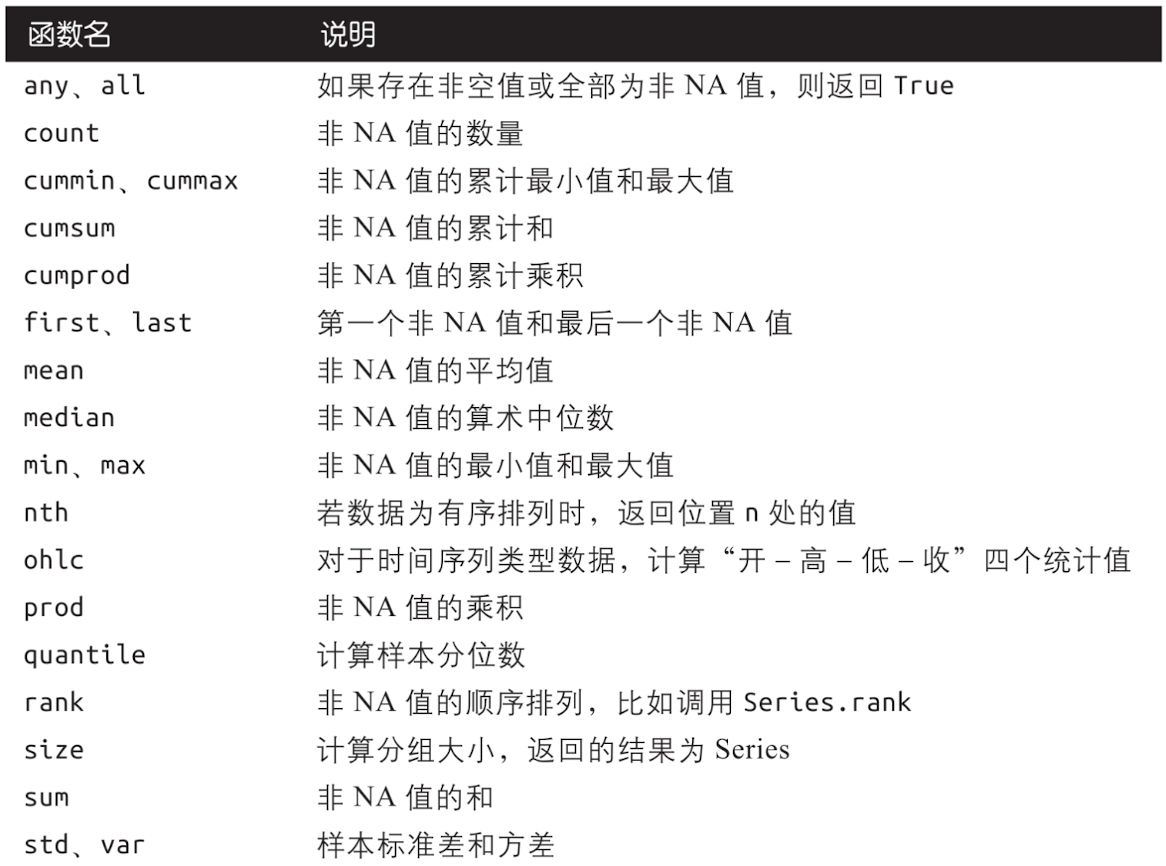

你可以使用自己定制的聚合算法，还可以调用分组对象上已经定义好的任何方法。例如，Series的nsmallest方法可以计算数据中的若干最小值。虽然nsmallest并不是特意为GroupBy实现的，没有经过实现优化，但仍然可以用于GroupBy对象。由表及里，GroupBy实际上是先对Series进行切片，然后对各片调用piece.nsmallest(n)，最后将这些结果组装成最终结果：

In [32]:
df

,key1,key2,data1,data2
0,a,1,0.986752,-0.157549
1,a,2,-0.405507,0.394556
2,None,1,0.299189,-0.865091
3,b,2,-0.200698,0.660541
4,b,1,-0.156605,2.050585
5,a,<NA>,0.191453,2.032655
6,None,1,-1.354255,1.324156


In [33]:
grouped = df.groupby('key1')
grouped['data1'].nsmallest(2)

key1   
a     1   -0.405507
      5    0.191453
b     3   -0.200698
      4   -0.156605
Name: data1, dtype: float64

要想使用自己的聚合函数，只需将能聚合数组的函数传入aggregate（或其缩写agg）方法：

In [34]:
def peak_to_peak(arr):
    return arr.max() - arr.min()
grouped.agg(peak_to_peak)

,key2,data1,data2
key1,,,
a,1,1.392258,2.190204
b,1,0.044093,1.390044


你可能注意到，某些方法（比如describe）也可以用于GroupBy，严格来讲，它们并非聚合运算：

In [35]:
grouped.describe()

key2                                           data1            ...  \
     count mean       std  min   25%  50%   75%  max count      mean  ...   
key1                                                                  ...   
a      2.0  1.5  0.707107  1.0  1.25  1.5  1.75  2.0   3.0  0.257566  ...   
b      2.0  1.5  0.707107  1.0  1.25  1.5  1.75  2.0   2.0 -0.178651  ...   

                         data2                                          \
           75%       max count      mean       std       min       25%   
key1                                                                     
a     0.589102  0.986752   3.0  0.756554  1.139092 -0.157549  0.118503   
b    -0.167628 -0.156605   2.0  1.355563  0.982909  0.660541  1.008052   

                                    
           50%       75%       max  
key1                                
a     0.394556  1.213605  2.032655  
b     1.355563  1.703074  2.050585  

[2 rows x 24 columns]

自定义的聚合函数通常要比表10-1中经过优化的函数慢得多。这是因为在构造中间分组数据块时存在非常大的开销（函数调用、数据重排）。

### 10.2.1 逐列操作和多函数应用

回到上一章的小费数据集。使用pandas.read_csv加载数据后，我们添加一个小费百分比的列：

In [36]:
tips = pd.read_csv('examples/tips.csv')
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


现在，用小费占总账单的百分比新增一个列tip_pct：


In [37]:
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,0.203927
240,27.18,2.00,Yes,Sat,Dinner,2,0.073584
241,22.67,2.00,Yes,Sat,Dinner,2,0.088222
242,17.82,1.75,No,Sat,Dinner,2,0.098204


你已经看到，对Series或DataFrame所有列的聚合运算其实就是使用aggregate（或agg）配合所需的函数，或者调用mean、std之类的方法。然而，你可能希望对不同的列使用不同的聚合函数，或一次应用多个函数。其实这也不难实现，我将通过一些例子进行示范。首先，我根据day和smoker对tips进行分组：

In [38]:
grouped = tips.groupby(['day', 'smoker'])

注意，对于表10-1中的描述性统计，可以将函数名以字符串的形式传入：

In [39]:
grouped_dict = grouped['tip_pct']
grouped_dict.agg('mean')

day   smoker
Fri   No        0.151650
      Yes       0.174783
Sat   No        0.158048
      Yes       0.147906
Sun   No        0.160113
      Yes       0.187250
Thur  No        0.160298
      Yes       0.163863
Name: tip_pct, dtype: float64

In [40]:
grouped_dict.agg(['mean', 'std', 'min', 'max'])

mean       std       min       max
day  smoker                                        
Fri  No      0.151650  0.028123  0.120385  0.187735
     Yes     0.174783  0.051293  0.103555  0.263480
Sat  No      0.158048  0.039767  0.056797  0.291990
     Yes     0.147906  0.061375  0.035638  0.325733
Sun  No      0.160113  0.042347  0.059447  0.252672
     Yes     0.187250  0.154134  0.065660  0.710345
Thur No      0.160298  0.038774  0.072961  0.266312
     Yes     0.163863  0.039389  0.090014  0.241255

这里，我们给agg传递了一个聚合函数的列表，这些函数会各自对数据分组进行评估。

你并非一定要接收GroupBy给出的那些列名。特别是lambda函数，它的名称是`<lambda>`，辨识度很低（可以查看函数的__name__属性）。因此，如果传入的是由(name，function)元组构成的列表，则各元组的第一个元素就会用作DataFrame的列名（可以将这种二元组列表当作有序映射）：


In [41]:
grouped_dict.agg([('average', 'mean'), ('std_dev', 'std'), ('minimum', 'min'), ('maximum', 'max')])

average   std_dev   minimum   maximum
day  smoker                                        
Fri  No      0.151650  0.028123  0.120385  0.187735
     Yes     0.174783  0.051293  0.103555  0.263480
Sat  No      0.158048  0.039767  0.056797  0.291990
     Yes     0.147906  0.061375  0.035638  0.325733
Sun  No      0.160113  0.042347  0.059447  0.252672
     Yes     0.187250  0.154134  0.065660  0.710345
Thur No      0.160298  0.038774  0.072961  0.266312
     Yes     0.163863  0.039389  0.090014  0.241255

对于DataFrame，你还有更多选择。你可以定义一个函数列表，应用到所有列，或者不同的列应用不同的函数。假设我们想要对tip_pct和total_bill列计算得到3个相同的统计值：

In [42]:
functions = ['count', 'mean', 'max']
result = grouped[['tip_pct', 'total_bill']].agg(functions)
result

tip_pct                     total_bill                  
              count      mean       max      count       mean    max
day  smoker                                                         
Fri  No           4  0.151650  0.187735          4  18.420000  22.75
     Yes         15  0.174783  0.263480         15  16.813333  40.17
Sat  No          45  0.158048  0.291990         45  19.661778  48.33
     Yes         42  0.147906  0.325733         42  21.276667  50.81
Sun  No          57  0.160113  0.252672         57  20.506667  48.17
     Yes         19  0.187250  0.710345         19  24.120000  45.35
Thur No          45  0.160298  0.266312         45  17.113111  41.19
     Yes         17  0.163863  0.241255         17  19.190588  43.11

如你所见，产生的DataFrame具有层次化的列，这相当于分别对各列进行聚合，然后将列名作为keys参数，并用concat方法将结果拼接到一起：

In [43]:
result['tip_pct']

count      mean       max
day  smoker                           
Fri  No          4  0.151650  0.187735
     Yes        15  0.174783  0.263480
Sat  No         45  0.158048  0.291990
     Yes        42  0.147906  0.325733
Sun  No         57  0.160113  0.252672
     Yes        19  0.187250  0.710345
Thur No         45  0.160298  0.266312
     Yes        17  0.163863  0.241255

与之前一样，这里也可以传入带有自定义名称的元组列表：

In [44]:
ftuples = [('Average', 'mean'), ('Variance', 'var')]
grouped[['tip_pct', 'total_bill']].agg(ftuples)

tip_pct           total_bill            
              Average  Variance    Average    Variance
day  smoker                                           
Fri  No      0.151650  0.000791  18.420000   25.596333
     Yes     0.174783  0.002631  16.813333   82.562438
Sat  No      0.158048  0.001581  19.661778   79.908965
     Yes     0.147906  0.003767  21.276667  101.387535
Sun  No      0.160113  0.001793  20.506667   66.099980
     Yes     0.187250  0.023757  24.120000  109.046044
Thur No      0.160298  0.001503  17.113111   59.625081
     Yes     0.163863  0.001551  19.190588   69.808518

现在，假设你想要对单列或多列应用不同的函数。具体的办法是向agg传入一个从列名映射到函数规范的字典：

In [45]:
grouped.agg({'tip': 'max',
             'size': 'sum',})

tip  size
day  smoker             
Fri  No       3.50     9
     Yes      4.73    31
Sat  No       9.00   115
     Yes     10.00   104
Sun  No       6.00   167
     Yes      6.50    49
Thur No       6.70   112
     Yes      5.00    40

In [46]:
grouped.agg({'tip_pct': ['min', 'max', 'mean', 'std'], 'size': 'sum'})

tip_pct                               size
                  min       max      mean       std  sum
day  smoker                                             
Fri  No      0.120385  0.187735  0.151650  0.028123    9
     Yes     0.103555  0.263480  0.174783  0.051293   31
Sat  No      0.056797  0.291990  0.158048  0.039767  115
     Yes     0.035638  0.325733  0.147906  0.061375  104
Sun  No      0.059447  0.252672  0.160113  0.042347  167
     Yes     0.065660  0.710345  0.187250  0.154134   49
Thur No      0.072961  0.266312  0.160298  0.038774  112
     Yes     0.090014  0.241255  0.163863  0.039389   40

### 10.2.2 返回不含行索引的聚合数据

对于到目前为止的所有示例，返回的聚合数据都具有索引（可能还是层次化索引），索引由唯一的用于分组的键组合构成。由于并不总是需要索引，因此你可以向groupby传入as_index=False以禁用该功能：


In [47]:
tips.groupby(['day', 'smoker'], as_index=False)[['total_bill', 'tip', 'size', 'tip_pct']].mean()


,day,smoker,total_bill,tip,size,tip_pct
0,Fri,No,18.420000,2.812500,2.250000,0.151650
1,Fri,Yes,16.813333,2.714000,2.066667,0.174783
2,Sat,No,19.661778,3.102889,2.555556,0.158048
3,Sat,Yes,21.276667,2.875476,2.476190,0.147906
4,Sun,No,20.506667,3.167895,2.929825,0.160113
5,Sun,Yes,24.120000,3.516842,2.578947,0.187250
6,Thur,No,17.113111,2.673778,2.488889,0.160298
7,Thur,Yes,19.190588,3.030000,2.352941,0.163863


当然，对结果调用reset_index也能得到这种形式的结果。使用as_index=False参数可以避免一些不必要的计算。

## 10.3 Apply：通用的“拆分-应用-联合”范式

GroupBy方法中最通用的是apply方法，它是本节的重点。apply会将待处理的对象拆分成多个片段，然后对各片段调用传入的函数，最后尝试将各片段拼接到一起。

回到之前的小费数据集，假设你想要根据分组选出最高的5个tip_pct值。首先，编写一个可以在特定列中选取最大值所在行的函数：

In [48]:
def top(df, n=5, column='tip_pct'):
    return df.sort_values(by=column, ascending=False)[:n]

top(tips, n=6)

,total_bill,tip,smoker,day,time,size,tip_pct
172,7.25,5.15,Yes,Sun,Dinner,2,0.710345
178,9.60,4.00,Yes,Sun,Dinner,2,0.416667
67,3.07,1.00,Yes,Sat,Dinner,1,0.325733
232,11.61,3.39,No,Sat,Dinner,2,0.291990
183,23.17,6.50,Yes,Sun,Dinner,4,0.280535
109,14.31,4.00,Yes,Sat,Dinner,2,0.279525


现在，如果按照smoker分组，随后调用apply以及该函数，就会得到：


In [49]:
tips.groupby('smoker').apply(top)

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/1695234324.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tips.groupby('smoker').apply(top)


total_bill   tip smoker   day    time  size   tip_pct
smoker                                                           
No     232       11.61  3.39     No   Sat  Dinner     2  0.291990
       149        7.51  2.00     No  Thur   Lunch     2  0.266312
       51        10.29  2.60     No   Sun  Dinner     2  0.252672
       185       20.69  5.00     No   Sun  Dinner     5  0.241663
       88        24.71  5.85     No  Thur   Lunch     2  0.236746
Yes    172        7.25  5.15    Yes   Sun  Dinner     2  0.710345
       178        9.60  4.00    Yes   Sun  Dinner     2  0.416667
       67         3.07  1.00    Yes   Sat  Dinner     1  0.325733
       183       23.17  6.50    Yes   Sun  Dinner     4  0.280535
       109       14.31  4.00    Yes   Sat  Dinner     2  0.279525

这里发生了什么？首先，基于smoker的值，将tips DataFrametop进行分组。然后在各个分组上调用函数top，结果由pandas.concat拼装到一起，并使用分组名作为各组的标签。于是，最终结果就有了一个层次化索引，其内层索引包含原DataFrame的索引值。

如果让传给apply的函数还接收其他参数或关键字，则可以将这些内容放在函数名后面一并传入：


In [50]:
tips.groupby(['smoker', 'day']).apply(top, n=1, column='total_bill')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/4096842605.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tips.groupby(['smoker', 'day']).apply(top, n=1, column='total_bill')


total_bill    tip smoker   day    time  size   tip_pct
smoker day                                                             
No     Fri  94        22.75   3.25     No   Fri  Dinner     2  0.142857
       Sat  212       48.33   9.00     No   Sat  Dinner     4  0.186220
       Sun  156       48.17   5.00     No   Sun  Dinner     6  0.103799
       Thur 142       41.19   5.00     No  Thur   Lunch     5  0.121389
Yes    Fri  95        40.17   4.73    Yes   Fri  Dinner     4  0.117750
       Sat  170       50.81  10.00    Yes   Sat  Dinner     3  0.196812
       Sun  182       45.35   3.50    Yes   Sun  Dinner     3  0.077178
       Thur 197       43.11   5.00    Yes  Thur   Lunch     4  0.115982

除了以上这些基本用法，要充分利用apply还需要一些创新性。使用者掌控着传入函数的内部细节，该函数必须返回一个pandas对象或一个标量值。本章剩余部分主要是用示例展示如何利用groupby解决各种问题。

例如，可能你已经回想起来了，之前我在GroupBy对象上调用过describe：

In [51]:
result = tips.groupby('smoker')["tip_pct"].describe()
result

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
No,151.0,0.159328,0.039910,0.056797,0.136906,0.155625,0.185014,0.291990
Yes,93.0,0.163196,0.085119,0.035638,0.106771,0.153846,0.195059,0.710345


In [52]:
result.unstack()

       smoker
count  No        151.000000
       Yes        93.000000
mean   No          0.159328
       Yes         0.163196
std    No          0.039910
       Yes         0.085119
min    No          0.056797
       Yes         0.035638
25%    No          0.136906
       Yes         0.106771
50%    No          0.155625
       Yes         0.153846
75%    No          0.185014
       Yes         0.195059
max    No          0.291990
       Yes         0.710345
dtype: float64

### 10.3.1 禁用分组键

从上面的例子中可以看出，分组键会与原始对象各分块的索引共同构成结果对象中的层次化索引。将group_keys=False传入groupby即可禁止该效果：

In [53]:
tips.groupby('smoker', group_keys=False).apply(top)

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/1502793219.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tips.groupby('smoker', group_keys=False).apply(top)


,total_bill,tip,smoker,day,time,size,tip_pct
232,11.61,3.39,No,Sat,Dinner,2,0.291990
149,7.51,2.00,No,Thur,Lunch,2,0.266312
51,10.29,2.60,No,Sun,Dinner,2,0.252672
185,20.69,5.00,No,Sun,Dinner,5,0.241663
88,24.71,5.85,No,Thur,Lunch,2,0.236746
172,7.25,5.15,Yes,Sun,Dinner,2,0.710345
178,9.60,4.00,Yes,Sun,Dinner,2,0.416667
67,3.07,1.00,Yes,Sat,Dinner,1,0.325733
183,23.17,6.50,Yes,Sun,Dinner,4,0.280535
109,14.31,4.00,Yes,Sat,Dinner,2,0.279525


### 10.3.2 分位数和桶分析

第8章曾讲过，pandas有一些能根据指定分箱或样本分位数将数据进行分桶的工具，特别是pandas.cut和pandas.qcut。将这些函数与groupby结合起来，能非常轻松地实现对数据集的桶分析或分位数分析。考虑下面这个简单的随机数据集，以及使用pandas.cut得到的等长桶分类：

In [54]:
frame = pd.DataFrame({'data1': np.random.standard_normal(1000),
                      'data2': np.random.standard_normal(1000)})
frame.head()

,data1,data2
0,-0.169420,-0.781416
1,1.587445,-0.887379
2,0.887521,0.378314
3,-0.535113,0.570199
4,-0.807095,1.153823


In [55]:
quartiles = pd.cut(frame['data1'], 4)
quartiles[:10]

0    (-1.023, 0.534]
1     (0.534, 2.091]
2     (0.534, 2.091]
3    (-1.023, 0.534]
4    (-1.023, 0.534]
5    (-1.023, 0.534]
6    (-1.023, 0.534]
7    (-1.023, 0.534]
8    (-1.023, 0.534]
9    (-1.023, 0.534]
Name: data1, dtype: category
Categories (4, interval[float64, right]): [(-2.586, -1.023] < (-1.023, 0.534] < (0.534, 2.091] < (2.091, 3.648]]

由cut返回的Categorical对象可直接传递给groupby。因此，我们可以如下计算分位数的分组统计集合：

In [56]:
def get_stats(group):
    return pd.DataFrame({'min': group.min(), 'max': group.max(),
            'count': group.count(), 'mean': group.mean()})

grouped = frame.groupby(quartiles)
grouped.apply(get_stats)

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/1113606163.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = frame.groupby(quartiles)


min       max  count      mean
data1                                                      
(-2.586, -1.023] data1 -2.579422 -1.025402    144 -1.529945
                 data2 -2.229075  2.065414    144 -0.079652
(-1.023, 0.534]  data1 -1.022313  0.534089    558 -0.212208
                 data2 -2.620996  2.800457    558  0.116610
(0.534, 2.091]   data1  0.544064  2.086432    270  1.075608
                 data2 -2.433966  2.547042    270 -0.045733
(2.091, 3.648]   data1  2.092156  3.648264     28  2.436947
                 data2 -1.326301  1.809403     28  0.261118

使用下面的方法可以更简便地得到相同结果：

In [57]:
grouped.agg(['min', 'max', 'count', 'mean'])

data1                               data2            \
                       min       max count      mean       min       max   
data1                                                                      
(-2.586, -1.023] -2.579422 -1.025402   144 -1.529945 -2.229075  2.065414   
(-1.023, 0.534]  -1.022313  0.534089   558 -0.212208 -2.620996  2.800457   
(0.534, 2.091]    0.544064  2.086432   270  1.075608 -2.433966  2.547042   
(2.091, 3.648]    2.092156  3.648264    28  2.436947 -1.326301  1.809403   

                                  
                 count      mean  
data1                             
(-2.586, -1.023]   144 -0.079652  
(-1.023, 0.534]    558  0.116610  
(0.534, 2.091]     270 -0.045733  
(2.091, 3.648]      28  0.261118

这些都是长度相等的桶。如果要根据样本分位数得到大小相等的桶，使用pandas.qcut即可。我们可以传入4作为桶的数量来计算样本分位数，传入labels=False以获取分位数的索引（而非区间）：

In [58]:
quartiles_samp = pd.qcut(frame['data1'], 4, labels=False)
quartiles_samp.head()

0    1
1    3
2    3
3    1
4    0
Name: data1, dtype: int64

In [59]:
grouped = frame.groupby(quartiles_samp)
grouped.apply(get_stats)

min       max  count      mean
data1                                           
0     data1 -2.579422 -0.698237    250 -1.235865
      data2 -2.229075  2.548530    250 -0.001497
1     data1 -0.689274 -0.003515    250 -0.336890
      data2 -2.476232  2.800457    250  0.098781
2     data1 -0.003009  0.669171    250  0.333351
      data2 -2.620996  2.590214    250  0.116912
3     data1  0.669704  3.648264    250  1.319101
      data2 -2.333206  2.547042    250 -0.019948

### 10.3.3 示例：用指定分组的值填充缺失值

在清洗缺失数据时，有时你会用dropna将其删除，而有时则可能想用固定值或由数据本身衍生出的值来填充空(NA)值。这时就得使用fillna这个工具了。在下面这个例子中，我用平均值填充空值：

In [60]:
s = pd.Series(np.random.standard_normal(6))
s[::2] = np.nan
s

0         NaN
1   -0.487213
2         NaN
3    0.561526
4         NaN
5    0.438962
dtype: float64

In [61]:
s.fillna(s.mean())

0    0.171092
1   -0.487213
2    0.171092
3    0.561526
4    0.171092
5    0.438962
dtype: float64

假设你需要对不同的分组填充不同的值。一种方法是将数据分组，并使用apply和一个能够对各数据块调用fillna的函数。下面是一些有关美国若干州的示例数据，将其分为东部地区和西部地区：

In [62]:
states = ['Ohio', 'New York', 'Vermont', 'Florida', 'Oregon', 'Nevada', 'California', 'Idaho']
group_key = ['East']*4 + ['West']*4
data = pd.Series(np.random.standard_normal(8), index=states)
data

Ohio          0.848249
New York      0.068827
Vermont       1.077484
Florida       0.090423
Oregon        0.823934
Nevada       -0.657845
California    1.507150
Idaho        -1.042867
dtype: float64

将其中一些值设置为缺失值：

In [63]:
data[['Vermont', 'Nevada', 'Idaho']] = np.nan
data

Ohio          0.848249
New York      0.068827
Vermont            NaN
Florida       0.090423
Oregon        0.823934
Nevada             NaN
California    1.507150
Idaho              NaN
dtype: float64

In [64]:
data.groupby(group_key).mean()

East    0.335833
West    1.165542
dtype: float64

In [65]:
def fill_mean(group):
    mean = group.mean()
    return group.fillna(mean)

data.groupby(group_key).apply(fill_mean)

East  Ohio          0.848249
      New York      0.068827
      Vermont       0.335833
      Florida       0.090423
West  Oregon        0.823934
      Nevada        1.165542
      California    1.507150
      Idaho         1.165542
dtype: float64

存在另外一种情况，你可能已经在代码中预设了针对各组的填充值。由于分组都具有内置的name属性，我们可以这样使用：

In [66]:
fill_values = {'East': 0.5, 'West': -1}
def fill_func(group):
    return group.fillna(fill_values[group.name])

data.groupby(group_key).apply(fill_func)

East  Ohio          0.848249
      New York      0.068827
      Vermont       0.500000
      Florida       0.090423
West  Oregon        0.823934
      Nevada       -1.000000
      California    1.507150
      Idaho        -1.000000
dtype: float64

### 10.3.4 示例：随机采样和排列

假设你想要从一个大型数据集中随机抽取（进行替换或不替换）样本，以进行蒙特卡罗模拟(Monte Carlo simulation)或其他工作。“抽取”的方式有很多，这里采用的是Series的sample方法。

为了进行演示，先来创建一副英氏扑克牌：

In [67]:
suits = ['H', 'S', 'C', 'D']
card_val = (list(range(1, 11)) + [10] * 3) * 4

base_names = ['A'] + list(range(2, 11)) + ['J', 'K', 'Q']

cards = []
for suit in suits:
    cards.extend(str(num) + suit for num in base_names)

deck = pd.Series(card_val, index=cards)

deck

AH      1
2H      2
3H      3
4H      4
5H      5
6H      6
7H      7
8H      8
9H      9
10H    10
JH     10
KH     10
QH     10
AS      1
2S      2
3S      3
4S      4
5S      5
6S      6
7S      7
8S      8
9S      9
10S    10
JS     10
KS     10
QS     10
AC      1
2C      2
3C      3
4C      4
5C      5
6C      6
7C      7
8C      8
9C      9
10C    10
JC     10
KC     10
QC     10
AD      1
2D      2
3D      3
4D      4
5D      5
6D      6
7D      7
8D      8
9D      9
10D    10
JD     10
KD     10
QD     10
dtype: int64

现在，根据我上面所讲的，从整副牌中随机抽出5张，代码如下：

In [68]:
def draw(deck, n=5):
    return deck.sample(n)
draw(deck)

2H     2
7H     7
6C     6
KD    10
7D     7
dtype: int64

假设你想从每种花色中随机抽取两张牌。由于花色是牌名的最后一个字符，因此我们可以使用apply据此进行分组：

In [69]:
def get_suit(card):
    return card[-1]

deck.groupby(get_suit).apply(draw, n=2)

C  AC     1
   KC    10
D  KD    10
   5D     5
H  KH    10
   8H     8
S  7S     7
   3S     3
dtype: int64

我们也可以传入group_keys=False，丢弃外层的花色索引，只保留选取的牌：

In [70]:
deck.groupby(get_suit, group_keys=False).apply(lambda x: x.sample(2))

KC    10
7C     7
9D     9
JD    10
8H     8
4H     4
4S     4
9S     9
dtype: int64

### 10.3.5 示例：分组加权平均和相关系数

根据groupby的“拆分-应用-联合”范式，可以进行DataFrame的列与列之间或两个Series之间的运算，比如分组加权平均。以下面这个数据集为例，它含有分组键、值以及一些权重值：

In [71]:
df = pd.DataFrame({'category': ['a', 'a', 'a', 'a', 'b', 'b', 'b', 'b'],
                   'data': np.random.standard_normal(8),
                   'weights': np.random.uniform(size=8)})
df

,category,data,weights
0,a,-0.061417,0.368826
1,a,-0.003372,0.426477
2,a,-0.850449,0.267908
3,a,-1.008300,0.596060
4,b,-2.291474,0.393924
5,b,0.158641,0.880279
6,b,0.515040,0.222350
7,b,0.130806,0.017785


然后可以利用category计算分组加权平均值：

In [72]:
grouped = df.groupby('category')

def get_wavg(group):
    return np.average(group['data'], weights=group['weights'])

grouped.apply(get_wavg)

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_30100/3057761376.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(get_wavg)


category
a   -0.514045
b   -0.426703
dtype: float64

另一个例子，考虑一个来自Yahoo！Finance的数据集，其中含有几只股票和标准普尔500指数（符号SPX）的收盘价：


In [75]:
close_px = pd.read_csv('examples/stock_px.csv', parse_dates=True, index_col=0)
close_px.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2214 entries, 2003-01-02 to 2011-10-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2214 non-null   float64
 1   MSFT    2214 non-null   float64
 2   XOM     2214 non-null   float64
 3   SPX     2214 non-null   float64
dtypes: float64(4)
memory usage: 86.5 KB


In [76]:
close_px.tail(4)

,AAPL,MSFT,XOM,SPX
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66
2011-10-14,422.00,27.27,78.11,1224.58


这里用到的是DataFrame的info()方法，可以便捷地获取DataFrame内容的全貌信息。

计算由日收益率（通过百分数变化计算）与SPX之间的年化相关系数组成的DataFrame，也许是一个令人感兴趣的任务。下面是一个实现办法，我们先创建一个函数，用它计算每列和"SPX"列对应的相关系数：

In [77]:
def spx_corr(group):
    return group.corrwith(group['SPX'])

接下来，我们使用pct_change计算close_px的百分比变化：


In [82]:
rets = close_px.pct_change().dropna()
rets

,AAPL,MSFT,XOM,SPX
2003-01-03,0.006757,0.001421,0.000684,-0.000484
2003-01-06,0.000000,0.017975,0.024624,0.022474
2003-01-07,-0.002685,0.019052,-0.033712,-0.006545
2003-01-08,-0.020188,-0.028272,-0.004145,-0.014086
2003-01-09,0.008242,0.029094,0.021159,0.019386
...,...,...,...,...
2011-10-10,0.051406,0.026286,0.036977,0.034125
2011-10-11,0.029526,0.002227,-0.000131,0.000544
2011-10-12,0.004747,-0.001481,0.011669,0.009795
2011-10-13,0.015515,0.008160,-0.010238,-0.002974


最后，我们按照年将百分比变化进行分组，可以用一个单行函数返回每个datetime标签的year属性，这样就从每行标签提取出年份了：

In [79]:
def get_year(x):
    return x.year

by_year = rets.groupby(get_year)
by_year.apply(spx_corr)

,AAPL,MSFT,XOM,SPX
2003,0.541124,0.745174,0.661265,1.0
2004,0.374283,0.588531,0.557742,1.0
2005,0.467540,0.562374,0.631010,1.0
2006,0.428267,0.406126,0.518514,1.0
2007,0.508118,0.658770,0.786264,1.0
2008,0.681434,0.804626,0.828303,1.0
2009,0.707103,0.654902,0.797921,1.0
2010,0.710105,0.730118,0.839057,1.0
2011,0.691931,0.800996,0.859975,1.0


当然，你还可以计算列与列之间的相关系数。这里，我们计算Apple和Microsoft的年度相关系数：


In [81]:
def corr_appl_msft(group):
    return group["AAPL"].corr(group['MSFT'])

by_year.apply(corr_appl_msft)

2003    0.480868
2004    0.259024
2005    0.300093
2006    0.161735
2007    0.417738
2008    0.611901
2009    0.432738
2010    0.571946
2011    0.581987
dtype: float64

### 10.3.6 分组线性回归

延续上一个例子的主题，只要函数返回的是pandas对象或标量值，就可以用groupby执行更复杂的分组统计分析。例如，我可以定义如下的regress函数（利用statsmodels计量经济学库）对各数据块执行普通最小二乘(Ordinary Least Squares，OLS)回归：

In [84]:
import statsmodels.api as sm

def regress(data, yvar, xvars):
    Y = data[yvar]
    X = data[xvars]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X)
    results = model.fit()
    return results.params

现在，为了计算AAPL对SPX收益率的年化线性回归，执行如下代码：

In [85]:
by_year.apply(regress, 'AAPL', ['SPX'])

,const,SPX
2003,0.000710,1.195406
2004,0.004201,1.363463
2005,0.003246,1.766415
2006,0.000080,1.645496
2007,0.003438,1.198761
2008,-0.001110,0.968016
2009,0.002954,0.879103
2010,0.001261,1.052608
2011,0.001514,0.806605


## 10.4 分组转换和“展开式”GroupBy运算

在10.3节中，我们学习了用于分组运算和转换的apply方法。还有另一个内置的transform方法，它类似于apply，但对能使用的函数有更多限制：

- 生成标量值，能传播到分组形状。
- 生成与输入分组具有相同形状的对象。
- 无法修改输入。
  
来看一个简单的示例：

In [86]:
df = pd.DataFrame({'key': ['a', 'b', 'c'] * 4,
                   'value': np.arange(12.)})
df

,key,value
0,a,0.0
1,b,1.0
2,c,2.0
3,a,3.0
4,b,4.0
5,c,5.0
6,a,6.0
7,b,7.0
8,c,8.0
9,a,9.0


按照键计算分组平均值：

In [89]:
g = df.groupby('key')['value']
g.mean()

key
a    4.5
b    5.5
c    6.5
Name: value, dtype: float64

假设我们想创建一个Series，它的形状与df['value']相同，但值替换为按照'key'的分组平均值。我们可以向transform传入一个计算单个分组平均值的函数：


In [90]:
def get_mean(group):
    return group.mean()

g.transform(get_mean)

0     4.5
1     5.5
2     6.5
3     4.5
4     5.5
5     6.5
6     4.5
7     5.5
8     6.5
9     4.5
10    5.5
11    6.5
Name: value, dtype: float64

对于内置的聚合函数，我们可以像GroupBy的agg方法那样，传入函数的字符串别名：

In [91]:
g.transform('mean')

0     4.5
1     5.5
2     6.5
3     4.5
4     5.5
5     6.5
6     4.5
7     5.5
8     6.5
9     4.5
10    5.5
11    6.5
Name: value, dtype: float64

类似于apply，transform可以使用能返回Series的函数，但结果必须与输入具有相同的大小。例如，我们可以使用一个辅助函数将各分组乘以2：

In [ ]:
def times_two(group):
    return group * 2

g.transform(times_two)

再复杂一点，我们可以计算各个分组的降序排名：

In [96]:
def get_ranks(group):
    return group.rank(ascending=False)
g.transform(get_ranks)

0     4.0
1     4.0
2     4.0
3     3.0
4     3.0
5     3.0
6     2.0
7     2.0
8     2.0
9     1.0
10    1.0
11    1.0
Name: value, dtype: float64

再考虑一个由简单聚合方法构成的分组转换函数：

In [97]:
def normalize(x):
    return (x - x.mean()) / x.std()

对于这种情况，使用transform或apply都可以获得等价的结果：

In [98]:
g.transform(normalize)

0    -1.161895
1    -1.161895
2    -1.161895
3    -0.387298
4    -0.387298
5    -0.387298
6     0.387298
7     0.387298
8     0.387298
9     1.161895
10    1.161895
11    1.161895
Name: value, dtype: float64

In [99]:
g.apply(normalize)

key    
a    0    -1.161895
     3    -0.387298
     6     0.387298
     9     1.161895
b    1    -1.161895
     4    -0.387298
     7     0.387298
     10    1.161895
c    2    -1.161895
     5    -0.387298
     8     0.387298
     11    1.161895
Name: value, dtype: float64

'mean'或'sum'等内置聚合函数通常比一般的apply函数快得多。这些函数在与transform配合使用时，也存在“高速运行路径”。我们借此可以实现展开式分组运算：

In [100]:
g.transform('mean')

0     4.5
1     5.5
2     6.5
3     4.5
4     5.5
5     6.5
6     4.5
7     5.5
8     6.5
9     4.5
10    5.5
11    6.5
Name: value, dtype: float64

In [101]:
normalized = (df['value'] - g.transform('mean')) / g.transform('std')
normalized

0    -1.161895
1    -1.161895
2    -1.161895
3    -0.387298
4    -0.387298
5    -0.387298
6     0.387298
7     0.387298
8     0.387298
9     1.161895
10    1.161895
11    1.161895
Name: value, dtype: float64

这里，我们直接在多个GroupBy运算输出的结果之间进行算数运算，而非编写一个函数，再将其传给groupby(...).apply。这就是“展开式”要表达的含义。

展开式分组运算中可能包含多个分组聚合运算，但向量化运算的整体收益往往更高。

## 10.5 透视表和交叉表

透视表是各种电子表格程序和其他数据分析软件中常见的数据汇总工具。它根据一个或多个键对数据进行聚合，并根据行和列上的分组键将数据分配到矩形区域中。在Python和pandas中，可以通过本章所介绍的groupby功能，结合使用层次化索引的重塑操作来制作透视表。DataFrame有一个pivot_table方法，此外还有一个顶级的pandas.pivot_table函数。除了为groupby提供便利的接口，pivot_table还可以添加分项汇总，也称作差额。

回到小费数据集，假设你想计算分组平均数（pivot_table的默认聚合类型），并在行方向上根据day和smoker排列

In [102]:
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808


In [105]:
tips[['day', 'smoker', 'size', 'tip', 'tip_pct', 'total_bill']].pivot_table(index=['day', 'smoker'])

size       tip   tip_pct  total_bill
day  smoker                                          
Fri  No      2.250000  2.812500  0.151650   18.420000
     Yes     2.066667  2.714000  0.174783   16.813333
Sat  No      2.555556  3.102889  0.158048   19.661778
     Yes     2.476190  2.875476  0.147906   21.276667
Sun  No      2.929825  3.167895  0.160113   20.506667
     Yes     2.578947  3.516842  0.187250   24.120000
Thur No      2.488889  2.673778  0.160298   17.113111
     Yes     2.352941  3.030000  0.163863   19.190588

可以通过groupby直接实现，即tips.groupby(["day"，"smoker"]).mean()。现在，假设我们只想对tip_pct和size求平均值，并根据time进行分组。我把smoker放到列上，把time和day放到行上：

In [106]:
tips.pivot_table(index=['time', 'day'], columns='smoker', 
                 values=['tip_pct', 'size'])

size             tip_pct          
smoker             No       Yes        No       Yes
time   day                                         
Dinner Fri   2.000000  2.222222  0.139622  0.165347
       Sat   2.555556  2.476190  0.158048  0.147906
       Sun   2.929825  2.578947  0.160113  0.187250
       Thur  2.000000       NaN  0.159744       NaN
Lunch  Fri   3.000000  1.833333  0.187735  0.188937
       Thur  2.500000  2.352941  0.160311  0.163863

通过传入margins=True添加分项汇总，我们还可以对这个表进行扩充。这会添加标签为All的行和列，对应的值为单行或单列中所有数据的分组统计值：

In [107]:
tips.pivot_table(index=["time", "day"], columns="smoker", values=["tip_pct", "size"], margins=True)

size                       tip_pct                    
smoker             No       Yes       All        No       Yes       All
time   day                                                             
Dinner Fri   2.000000  2.222222  2.166667  0.139622  0.165347  0.158916
       Sat   2.555556  2.476190  2.517241  0.158048  0.147906  0.153152
       Sun   2.929825  2.578947  2.842105  0.160113  0.187250  0.166897
       Thur  2.000000       NaN  2.000000  0.159744       NaN  0.159744
Lunch  Fri   3.000000  1.833333  2.000000  0.187735  0.188937  0.188765
       Thur  2.500000  2.352941  2.459016  0.160311  0.163863  0.161301
All          2.668874  2.408602  2.569672  0.159328  0.163196  0.160803

这里，All的值为平均值，没有考虑吸烟者与非吸烟者（All列），也没有考虑行上（All行）的任意两个分组层级。

要使用mean以外的其他聚合函数，可以将其传给aggfunc关键字参数。例如，使用"count"或len（"count"会排除分组数据计数中的空值，而len不会）可以得到有关分组大小的交叉表（计数或频率）：

In [109]:
tips.pivot_table(
    index=["time", "day"], columns="smoker", values=["tip_pct", "size"], margins=True,
    aggfunc=len
)

size            tip_pct           
smoker          No   Yes  All      No   Yes  All
time   day                                      
Dinner Fri     3.0   9.0   12     3.0   9.0   12
       Sat    45.0  42.0   87    45.0  42.0   87
       Sun    57.0  19.0   76    57.0  19.0   76
       Thur    1.0   NaN    1     1.0   NaN    1
Lunch  Fri     1.0   6.0    7     1.0   6.0    7
       Thur   44.0  17.0   61    44.0  17.0   61
All          151.0  93.0  244   151.0  93.0  244

如果某些组合为空（也就是NA），可以传入fill_value以填充值：


In [110]:
tips.pivot_table(index=['time', 'size', 'smoker'], columns='day', values='tip_pct', fill_value=0)

day                      Fri       Sat       Sun      Thur
time   size smoker                                        
Dinner 1    No      0.000000  0.137931  0.000000  0.000000
            Yes     0.000000  0.325733  0.000000  0.000000
       2    No      0.139622  0.162705  0.168859  0.159744
            Yes     0.171297  0.148668  0.207893  0.000000
       3    No      0.000000  0.154661  0.152663  0.000000
            Yes     0.000000  0.144995  0.152660  0.000000
       4    No      0.000000  0.150096  0.148143  0.000000
            Yes     0.117750  0.124515  0.193370  0.000000
       5    No      0.000000  0.000000  0.206928  0.000000
            Yes     0.000000  0.106572  0.065660  0.000000
       6    No      0.000000  0.000000  0.103799  0.000000
Lunch  1    No      0.000000  0.000000  0.000000  0.181728
            Yes     0.223776  0.000000  0.000000  0.000000
       2    No      0.000000  0.000000  0.000000  0.166005
            Yes     0.181969  0.000000  0.000000  0.158843
       3    No      0.187735  0.000000  0.000000  0.084246
            Yes     0.000000  0.000000  0.000000  0.204952
       4    No      0.000000  0.000000  0.000000  0.138919
            Yes     0.000000  0.000000  0.000000  0.155410
       5    No      0.000000  0.000000  0.000000  0.121389
       6    No      0.000000  0.000000  0.000000  0.173706

**pivot_table选项:**

![表10-2 pivot_table选项.png](<attachment:表10-2 pivot_table选项.png>)
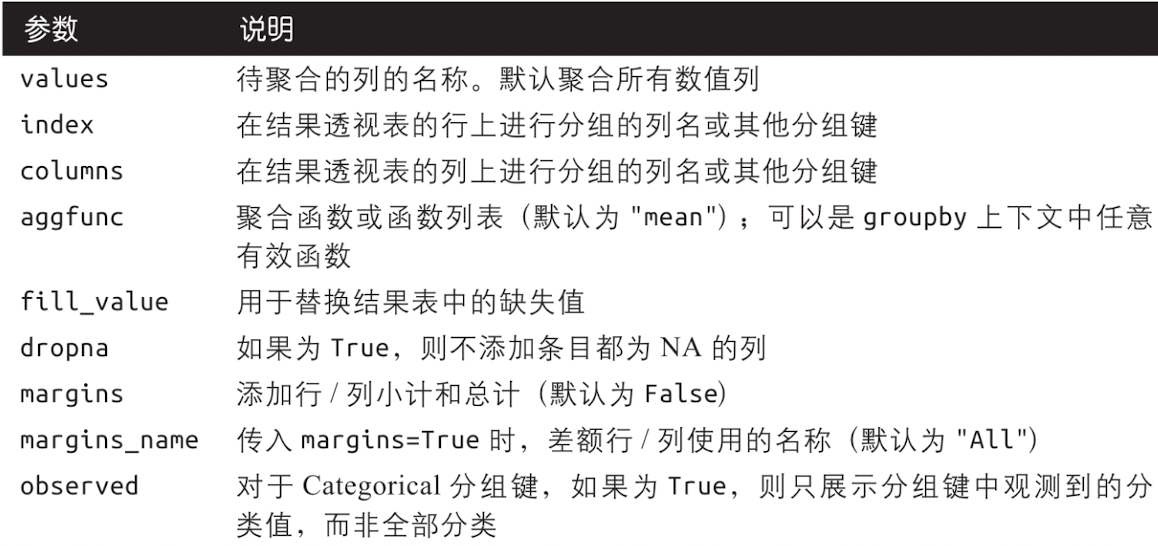

**交叉表**（cross-tabulation，简称crosstab）是一种用于计算分组频次的特殊透视表。看下面的示例：

In [112]:
from io import StringIO

data = """\
Sample  Nationality  Handedness
1   USA  Right-handed
2   Japan    Left-handed
3   USA  Right-handed
4   Japan    Right-handed
5   Japan    Left-handed
6   Japan    Right-handed
7   USA  Right-handed
8   USA  Left-handed
9   Japan    Right-handed
10  USA  Right-handed"""

data = pd.read_table(StringIO(data), sep=r'\s+')
data

,Sample,Nationality,Handedness
0,1,USA,Right-handed
1,2,Japan,Left-handed
2,3,USA,Right-handed
3,4,Japan,Right-handed
4,5,Japan,Left-handed
5,6,Japan,Right-handed
6,7,USA,Right-handed
7,8,USA,Left-handed
8,9,Japan,Right-handed
9,10,USA,Right-handed


作为调查分析的一部分，我们可能想根据国籍和用手习惯对这段数据进行统计汇总。虽然可以用pivot_table实现该功能，但是pandas.crosstab函数会更方便：


In [113]:
pd.crosstab(data['Nationality'], data['Handedness'], margins=True)

Handedness,Left-handed,Right-handed,All
Nationality,,,
Japan,2,3,5
USA,1,4,5
All,3,7,10


In [114]:
pd.crosstab([tips['time'], tips['day']], tips['smoker'], margins=True)

smoker        No  Yes  All
time   day                
Dinner Fri     3    9   12
       Sat    45   42   87
       Sun    57   19   76
       Thur    1    0    1
Lunch  Fri     1    6    7
       Thur   44   17   61
All          151   93  244